In [1]:
# Cell 1 - Install required packages
# kagglehub: download datasets from Kaggle
# opencv-headless: image processing (no GUI needed in Colab)
# scikit-learn: metrics and data splitting
# matplotlib/seaborn: plotting

!pip install kagglehub opencv-python-headless scikit-learn matplotlib seaborn --quiet

print("All packages installed successfully.")


All packages installed successfully.


In [2]:
# Cell 2 - Imports and global settings
# All libraries imported here so they're easy to find

# Standard library

import os           # file-system operations (directory walking, path joining)
import random       # random sampling for demo predictions
import warnings
import pickle       # serialize / deserialize the LabelEncoder object
import io           # in-memory byte streams (used in webcam cell)

warnings.filterwarnings('ignore')   # suppress non-critical deprecation noise

# ── Numerical computing ───────────────────────────────────────────────────────
import numpy as np   # array operations, argmax, normalisation
import pandas as pd  # tabular EDA — storing image paths and labels

# ── Image I/O and processing ──────────────────────────────────────────────────
import cv2           # fast image read / resize / colour conversion
from PIL import Image   # used for EDA dimension analysis (Pillow)

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # training curves, sample grids
import seaborn as sns             # confusion-matrix heatmap

# ── Machine-learning utilities ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split   # 70/15/15 split
from sklearn.preprocessing import LabelEncoder         # text label → integer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# ── Deep-learning framework ───────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,        # stop training when val_loss stops improving
    ReduceLROnPlateau,    # lower learning rate when training plateaus
    ModelCheckpoint       # save the best model weights automatically
)
from tensorflow.keras.utils import to_categorical   # integer → one-hot vector

# ── Kaggle dataset downloader ─────────────────────────────────────────────────
import kagglehub

# ── Reproducibility ───────────────────────────────────────────────────────────
# Setting the same seed across all libraries ensures that results are
# reproducible every time the notebook is run from top to bottom.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Global hyperparameters and constants ──────────────────────────────────────
IMG_SIZE   = 128   # each face image is resized to 128 x 128 pixels
BATCH_SIZE = 32    # number of images processed per gradient update
EPOCHS     = 50    # maximum training epochs (EarlyStopping will cut this short)
MIN_IMAGES = 20    # minimum images a person must have to be included as a class
                   # persons with fewer images are removed to avoid under-fitting

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")


TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Cell 3 - Download the LFW dataset via kagglehub
# LFW = Labeled Faces in the Wild, 13k+ images of ~5,700 people
# kagglehub caches the download so re-running is fast

# The zip unpacks to a nested folder structure, so we search for the image root

path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", path)

# ── Locate the actual image root directory ────────────────────────────────────
# The Kaggle zip unpacks to a nested structure:
#   <path>/lfw-deepfunneled/lfw-deepfunneled/<person_name>/<image>.jpg
# We try to build the known path directly first (most reliable), then fall back
# to a recursive search if the directory layout differs.

# Attempt 1: construct the known nested path directly
_direct = os.path.join(path, "lfw-deepfunneled", "lfw-deepfunneled")
if os.path.isdir(_direct):
    DATA_ROOT = _direct
else:
    # Attempt 2: walk the tree and find the first directory whose immediate
    # children are themselves directories containing .jpg files.
    DATA_ROOT = None
    for root, dirs, files in os.walk(path):
        if not dirs:
            continue   # leaf directory — skip
        # Check whether the first child subdir contains image files
        sample_child = os.path.join(root, dirs[0])
        child_files  = os.listdir(sample_child)
        if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in child_files):
            DATA_ROOT = root
            break

    # Attempt 3: ultimate fallback — parent of any .jpg file
    if DATA_ROOT is None:
        for root, dirs, files in os.walk(path):
            if any(f.lower().endswith('.jpg') for f in files):
                DATA_ROOT = os.path.dirname(root)
                break

if DATA_ROOT is None:
    raise RuntimeError("Could not locate image directory. Re-download the dataset.")

print(f"\nImage root directory : {DATA_ROOT}")
print(f"Persons found        : {len(os.listdir(DATA_ROOT))}")


Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset

Image root directory : /kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled
Persons found        : 5749


In [4]:
# Cell 4 - Build a DataFrame with image paths and labels
# Walk the dataset directory and record person name + filepath for every image

records = []   # list of dicts — one per image file

for person in sorted(os.listdir(DATA_ROOT)):
    person_dir = os.path.join(DATA_ROOT, person)
    if not os.path.isdir(person_dir):
        continue   # skip any stray files at the root level

    for fname in os.listdir(person_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            records.append({
                'person'   : person,                              # class label
                'filename' : fname,
                'filepath' : os.path.join(person_dir, fname)     # absolute path
            })

# Convert to a pandas DataFrame for easy EDA queries
df = pd.DataFrame(records)

# ── Summary statistics ────────────────────────────────────────────────────────
print("=" * 55)
print(" LFW DATASET — SUMMARY STATISTICS")
print("=" * 55)
print(f" Total images          : {len(df):,}")
print(f" Total unique persons  : {df['person'].nunique():,}")
print(f" Avg images / person   : {df.groupby('person').size().mean():.2f}")
print(f" Max images / person   : {df.groupby('person').size().max()}")
print(f" Min images / person   : {df.groupby('person').size().min()}")
print("=" * 55)


 LFW DATASET — SUMMARY STATISTICS
 Total images          : 13,233
 Total unique persons  : 5,749
 Avg images / person   : 2.30
 Max images / person   : 530
 Min images / person   : 1


In [5]:
# Cell 5 - Check image dimensions and missing values
# Sample 200 images to get typical width/height stats
# Also confirm there are no NaN values in the DataFrame

sample_paths = df['filepath'].sample(200, random_state=SEED).tolist()
heights, widths = [], []

for p in sample_paths:
    try:
        img = Image.open(p)
        w, h = img.size   # Pillow returns (width, height)
        widths.append(w)
        heights.append(h)
    except Exception:
        pass   # silently skip any unreadable file

print(f" Image widths  — mean: {np.mean(widths):.1f},  std: {np.std(widths):.1f}")
print(f" Image heights — mean: {np.mean(heights):.1f}, std: {np.std(heights):.1f}")

# ── Missing value check ───────────────────────────────────────────────────────
# Our DataFrame is built from os.listdir(), so NaN values should not exist,
# but we confirm this explicitly for completeness.
print("\n── Missing Values in DataFrame ──")
print(df.isnull().sum())
print(f"\n Corrupt / unreadable images in 200-sample: {200 - len(heights)}")


 Image widths  — mean: 250.0,  std: 0.0
 Image heights — mean: 250.0, std: 0.0

── Missing Values in DataFrame ──
person      0
filename    0
filepath    0
dtype: int64

 Corrupt / unreadable images in 200-sample: 0


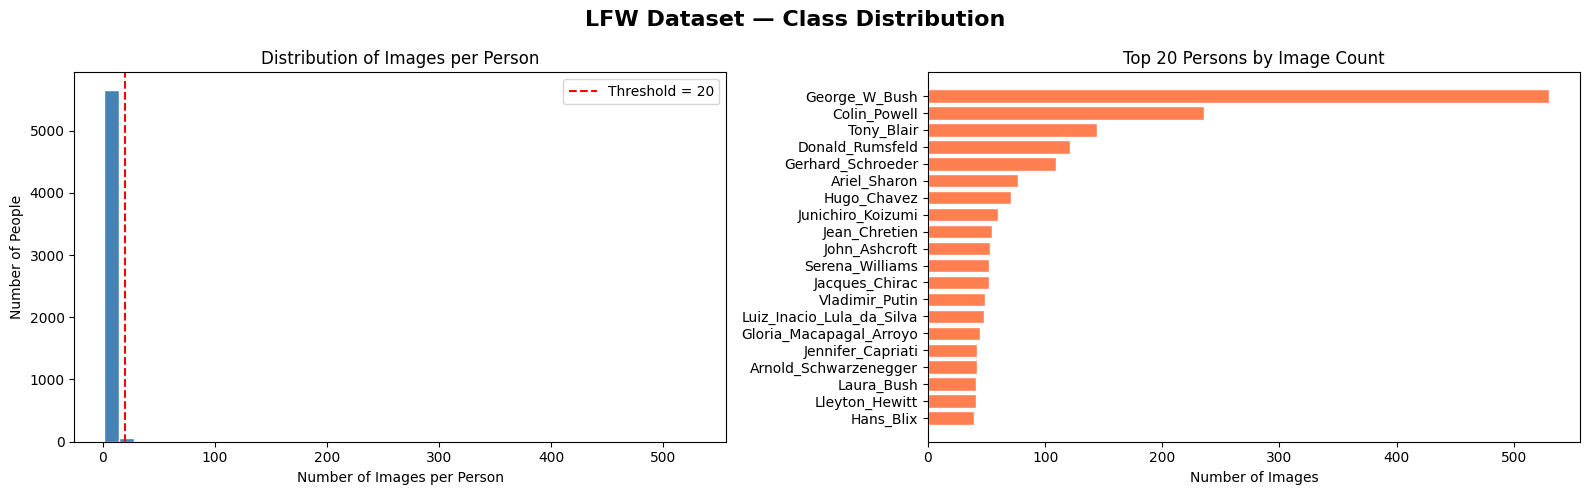

In [6]:
# Cell 6 - Visualise class distribution
# LFW is very imbalanced - most people have only 1-2 images
# Left: histogram of images per person  Right: top 20 people

counts = df.groupby('person').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('LFW Dataset — Class Distribution', fontsize=16, fontweight='bold')

# Left panel: histogram of images-per-person counts
axes[0].hist(counts.values, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Number of Images per Person')
axes[0].set_ylabel('Number of People')
axes[0].set_title('Distribution of Images per Person')
# Red dashed line marks the MIN_IMAGES threshold used for class filtering
axes[0].axvline(MIN_IMAGES, color='red', linestyle='--',
                label=f'Threshold = {MIN_IMAGES}')
axes[0].legend()

# Right panel: horizontal bar chart for the top 20 persons
top20 = counts.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='coral', edgecolor='white')
axes[1].set_xlabel('Number of Images')
axes[1].set_title('Top 20 Persons by Image Count')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


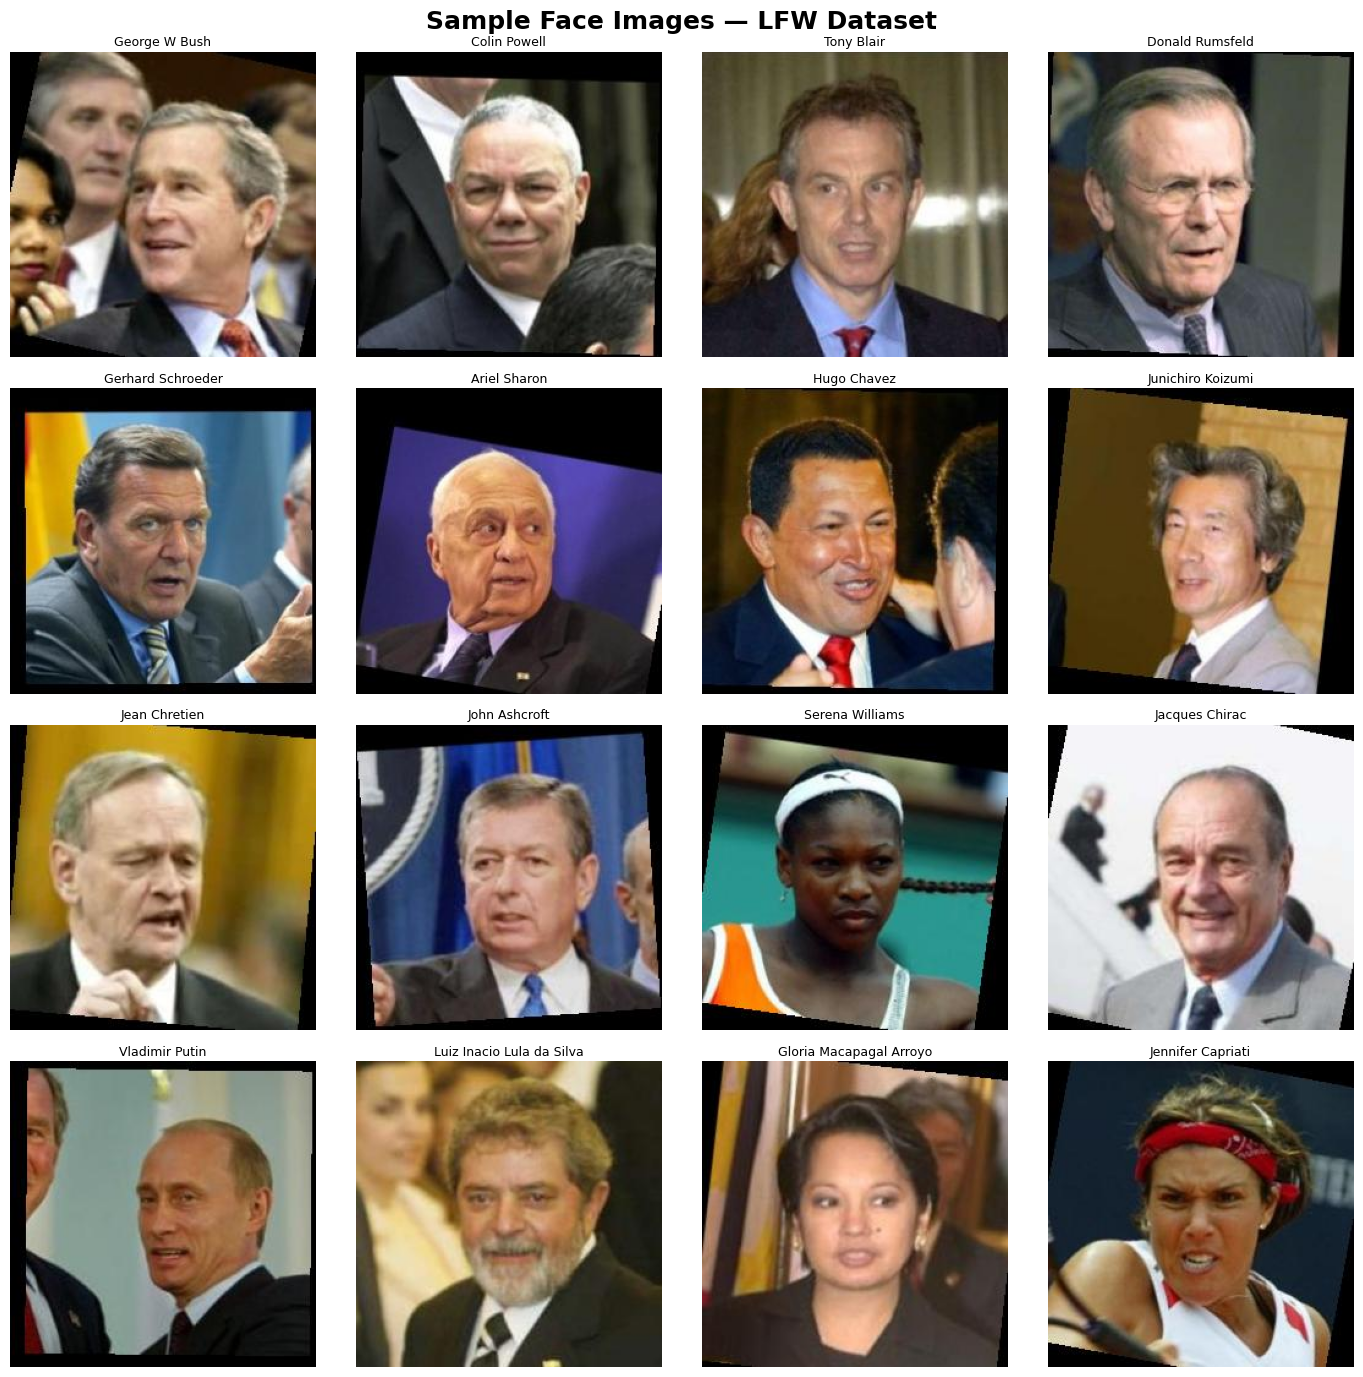

In [7]:
# Cell 7 - Show sample face images
# Display one random image per person for the 16 most common identities

top16_persons = counts.head(16).index.tolist()

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Sample Face Images — LFW Dataset', fontsize=18, fontweight='bold')

for ax, person in zip(axes.flatten(), top16_persons):
    # Collect all image paths for this person and pick one at random
    person_imgs = df[df['person'] == person]['filepath'].tolist()
    img_path    = random.choice(person_imgs)
    img         = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    # Display the person's name (underscores replaced with spaces for readability)
    ax.set_title(person.replace('_', ' '), fontsize=9, pad=4)
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_sample_faces.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# Cell 8 - Filter out classes with too few images
# Keep only people with >= MIN_IMAGES photos so each class can be properly split

filtered_persons = counts[counts >= MIN_IMAGES].index.tolist()

# Subset the full DataFrame to only the qualifying persons
df_filtered = df[df['person'].isin(filtered_persons)].copy()

# Total number of identity classes the model will distinguish
NUM_CLASSES = len(filtered_persons)

print(f"Persons after filtering (>= {MIN_IMAGES} images) : {NUM_CLASSES}")
print(f"Total images in filtered dataset               : {len(df_filtered):,}")


Persons after filtering (>= 20 images) : 62
Total images in filtered dataset               : 3,023


In [9]:
# Cell 9 - Load and normalise all images into a numpy array
# cv2.imread() returns None for corrupt files without raising an error,
# so we check for None explicitly before processing

def load_image(path, size=IMG_SIZE):
    """
    Read an image from disk, convert to RGB, resize, and normalise.

    Args:
        path : Absolute path to the image file.
        size : Target square dimension (pixels).

    Returns:
        float32 numpy array of shape (size, size, 3) with values in [0, 1].

    Raises:
        ValueError : If cv2.imread() cannot read the file (returns None).
    """
    img = cv2.imread(path)   # reads as BGR uint8; returns None on failure

    # BUG FIX: guard against None before any further processing
    if img is None:
        raise ValueError(f"cv2.imread returned None for path: {path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # convert BGR → RGB
    img = cv2.resize(img, (size, size))           # resize to (size x size)
    img = img.astype(np.float32) / 255.0          # normalise pixels to [0, 1]
    return img

print("Loading images — this may take a few minutes on Colab free tier ...")
X, y_raw = [], []

for _, row in df_filtered.iterrows():
    try:
        img = load_image(row['filepath'])
        X.append(img)
        y_raw.append(row['person'])   # keep the string label in sync with X
    except (ValueError, Exception):
        # Skip any image that fails to load (corrupt file, permission error, etc.)
        pass

# Stack the list of (128, 128, 3) arrays into a single 4-D array
X = np.array(X, dtype=np.float32)   # shape: (N, 128, 128, 3)

print(f"\nLoaded array shape : {X.shape}")
print(f"Memory usage       : {X.nbytes / 1e6:.1f} MB")
print(f"Pixel value range  : [{X.min():.3f}, {X.max():.3f}]")   # should be [0, 1]


Loading images — this may take a few minutes on Colab free tier ...

Loaded array shape : (3023, 128, 128, 3)
Memory usage       : 594.3 MB
Pixel value range  : [0.000, 1.000]


In [10]:
# Cell 10 - Encode string labels as integers, then as one-hot vectors
# Neural networks need numbers, not names.
# y_int is used for stratified splitting, y_cat for training

le = LabelEncoder()
y_int = le.fit_transform(y_raw)                      # shape: (N,)  — integers
y_cat = to_categorical(y_int, num_classes=NUM_CLASSES)  # shape: (N, NUM_CLASSES) — one-hot

print(f"Number of classes : {NUM_CLASSES}")
print(f"y_int shape       : {y_int.shape}   (integer labels)")
print(f"y_cat shape       : {y_cat.shape}  (one-hot labels)")
print(f"First 5 classes   : {list(le.classes_[:5])}")


Number of classes : 62
y_int shape       : (3023,)   (integer labels)
y_cat shape       : (3023, 62)  (one-hot labels)
First 5 classes   : [np.str_('Alejandro_Toledo'), np.str_('Alvaro_Uribe'), np.str_('Amelie_Mauresmo'), np.str_('Andre_Agassi'), np.str_('Angelina_Jolie')]


In [11]:
# Cell 11 - Split data: 70% train / 15% val / 15% test
# Two stratified splits so each class is proportionally represented.
# Second split uses test_size=0.1765 because 0.1765 * 0.85 ≈ 0.15

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_cat,
    test_size=0.15,
    random_state=SEED,
    stratify=y_int           # use integer labels for stratification
)

# Convert one-hot back to integers so we can stratify the second split
y_temp_int = np.argmax(y_temp, axis=1)

# Second split: 70 % train + 15 % validation (from the 85 % temp pool)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,        # 0.1765 × 0.85 ≈ 0.15 of the full dataset
    random_state=SEED,
    stratify=y_temp_int
)

print(f"Training   set : {X_train.shape}  —  {len(X_train)} images")
print(f"Validation set : {X_val.shape}  —  {len(X_val)} images")
print(f"Test       set : {X_test.shape}  —  {len(X_test)} images")


Training   set : (2115, 128, 128, 3)  —  2115 images
Validation set : (454, 128, 128, 3)  —  454 images
Test       set : (454, 128, 128, 3)  —  454 images


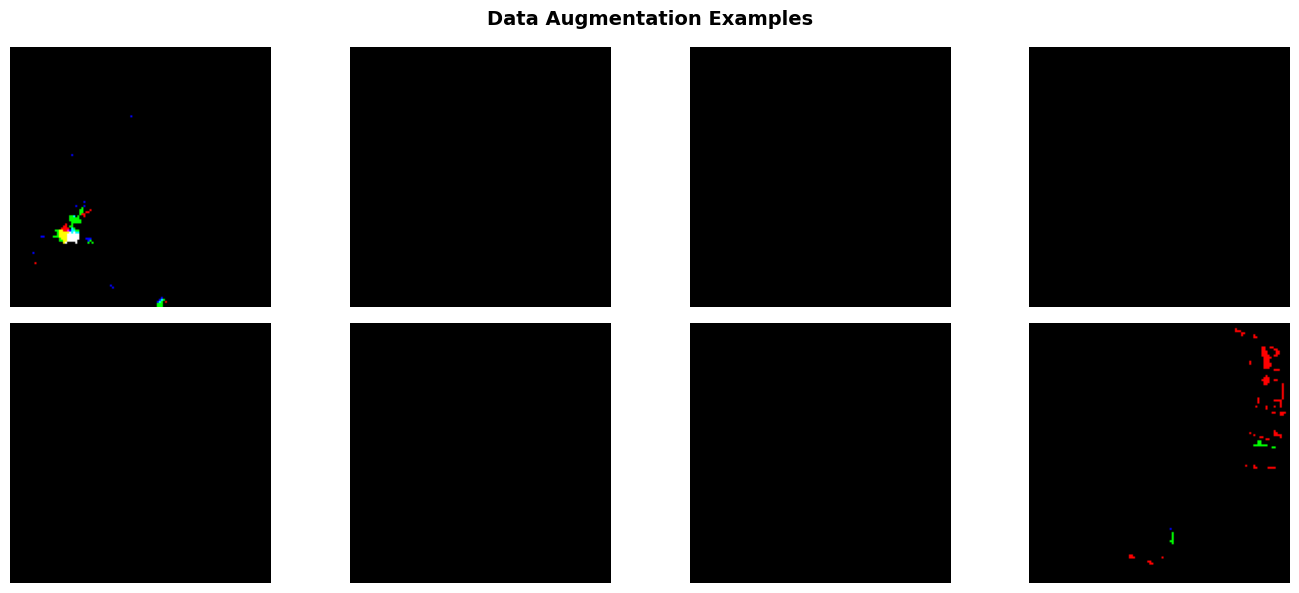

In [12]:
# Cell 12 - Data augmentation (training set only)
# Creates randomly modified images on-the-fly to reduce overfitting.
# brightness_range can push values above 1.0, so we clip back to [0,1]

def clip_to_unit(img):
    """Clip pixel values to the valid [0, 1] range after augmentation."""
    return np.clip(img, 0.0, 1.0)

# Training generator: applies random geometric and colour transforms
train_datagen = ImageDataGenerator(
    rotation_range=20,              # random rotation up to ±20 degrees
    width_shift_range=0.1,          # random horizontal shift up to 10 %
    height_shift_range=0.1,         # random vertical shift up to 10 %
    horizontal_flip=True,           # randomly mirror the face left-right
    zoom_range=0.1,                 # random zoom in/out up to 10 %
    brightness_range=[0.8, 1.2],    # vary brightness (may exceed 1.0)
    fill_mode='nearest',            # fill newly created pixels with nearest value
    preprocessing_function=clip_to_unit  # BUG FIX: clamp back to [0, 1]
)

# Validation generator: NO augmentation — we evaluate on clean data
val_datagen = ImageDataGenerator()

# Create iterators that yield (batch_of_images, batch_of_labels) on each step
train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

# ── Visualise a batch of augmented images ────────────────────────────────────
# Generate one batch purely for display — uses a temporary generator with no clip
_viz_gen   = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
sample_imgs, _ = next(_viz_gen.flow(X_train[:8], y_train[:8], batch_size=8))

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    ax.imshow(np.clip(sample_imgs[i], 0, 1))   # clip only for display safety
    ax.axis('off')
plt.tight_layout()
plt.savefig('augmentation_samples.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# Cell 13 - Define the CNN architecture
# 4 conv blocks (32 -> 64 -> 128 -> 256 filters), each with:
#   BatchNorm + ReLU + MaxPool + Dropout
# Then GlobalAveragePooling -> Dense(512) -> Dense(256) -> Softmax output
# L2 regularisation added to conv and dense layers to reduce overfitting

def build_cnn(input_shape, num_classes):
    """
    Build and compile the face recognition CNN.

    Args:
        input_shape : Tuple (H, W, C) — e.g. (128, 128, 3)
        num_classes : Number of identity classes to classify

    Returns:
        Compiled keras.Model
    """
    inputs = keras.Input(shape=input_shape, name='input')

    # ── Reusable convolutional block ──────────────────────────────────────────
    def conv_block(x, filters, kernel_size=3, pool=True, dropout_rate=0.25):
        """
        Two stacked Conv2D layers, each followed by BatchNorm and ReLU.
        Optional MaxPooling halves the spatial dimensions.
        Dropout reduces co-adaptation of feature detectors.
        """
        # First convolution
        x = layers.Conv2D(filters, kernel_size, padding='same',
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        # Second convolution (same filter count — deepens representation)
        x = layers.Conv2D(filters, kernel_size, padding='same',
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        if pool:
            # Halve spatial size (e.g. 128→64, 64→32, …)
            x = layers.MaxPooling2D(pool_size=2, strides=2)(x)
        x = layers.Dropout(dropout_rate)(x)
        return x

    # ── Feature extraction backbone ───────────────────────────────────────────
    x = conv_block(inputs, 32,  pool=True, dropout_rate=0.25)  # → 64×64×32
    x = conv_block(x,      64,  pool=True, dropout_rate=0.25)  # → 32×32×64
    x = conv_block(x,      128, pool=True, dropout_rate=0.25)  # → 16×16×128
    x = conv_block(x,      256, pool=True, dropout_rate=0.25)  # →  8×8×256

    # ── Spatial aggregation ───────────────────────────────────────────────────
    # GlobalAveragePooling reduces (8, 8, 256) → (256,) by averaging each map
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # ── Classification head ───────────────────────────────────────────────────
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.50)(x)   # heavier dropout near the output

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.40)(x)

    # Output layer: one neuron per class, softmax → probabilities sum to 1
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs, name='FaceRecognition_CNN')

    # Adam is an adaptive optimizer well suited for image classification tasks.
    # categorical_crossentropy is the standard loss for multi-class one-hot targets.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Instantiate the model and print the layer-by-layer summary
model = build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)
model.summary()


Model: "FaceRecognition_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,458,014 (5.56 MB)

 Trainable params: 1,454,558 (5.55 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [14]:
# Cell 14 - Train the model
# Callbacks used:
#   EarlyStopping: stop when val_loss stops improving (patience=10)
#   ReduceLROnPlateau: halve the learning rate after 5 stagnant epochs
#   ModelCheckpoint: save best weights (.keras format, not .h5 which is deprecated)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,               # wait 10 epochs before stopping
        restore_best_weights=True, # roll back to the best epoch automatically
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,        # new_lr = current_lr * 0.5
        patience=5,        # wait 5 epochs before reducing
        min_lr=1e-7,       # floor to prevent LR from reaching zero
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_face_cnn.keras',   # BUG FIX: .keras instead of .h5
        monitor='val_accuracy',
        save_best_only=True,              # only overwrite when val_accuracy improves
        verbose=1
    )
]

# ── Compute steps per epoch ───────────────────────────────────────────────────
# steps_per_epoch = how many batches the generator produces in one epoch
steps_per_epoch  = len(X_train) // BATCH_SIZE
validation_steps = len(X_val)   // BATCH_SIZE

# ── Run training ──────────────────────────────────────────────────────────────
history = model.fit(
    train_gen,
    steps_per_epoch  = steps_per_epoch,
    epochs           = EPOCHS,
    validation_data  = val_gen,
    validation_steps = validation_steps,
    callbacks        = callbacks,
    verbose          = 1
)

print("\nTraining complete!")


Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.0828 - loss: 4.5021
Epoch 1: val_accuracy improved from None to 0.17411, saving model to best_face_cnn.keras

Epoch 1: finished saving model to best_face_cnn.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 425ms/step - accuracy: 0.1210 - loss: 4.3524 - val_accuracy: 0.1741 - val_loss: 4.0219 - learning_rate: 0.0010
Epoch 2/50
 1/66 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.2188 - loss: 4.1145
Epoch 2: val_accuracy did not improve from 0.17411
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2188 - loss: 4.1145 - val_accuracy: 0.1741 - val_loss: 4.0188 - learning_rate: 0.0010
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.1364 - loss: 4.1763
Epoch 3: val_accuracy did not improve from 0.17411
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.1512 - loss: 4.1223 - val_accuracy: 0.1741 - val_loss: 3.9930 - learning_rate: 0.0010
Epoch 4/50
 1/66 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.0625 - lo

In [15]:
# Cell 15 - Evaluate on the test set
# Test set was never seen during training so these metrics are unbiased.
# Using weighted averages so class imbalance is accounted for

y_pred_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)

# Convert probability vectors to predicted class indices
y_pred = np.argmax(y_pred_prob, axis=1)   # shape: (N,)
y_true = np.argmax(y_test,      axis=1)   # shape: (N,)

# Compute scalar evaluation metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true,   y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true,       y_pred, average='weighted', zero_division=0)

print("=" * 45)
print(" TEST SET PERFORMANCE")
print("=" * 45)
print(f" Accuracy  : {acc  * 100:.2f} %")
print(f" Precision : {prec * 100:.2f} %")
print(f" Recall    : {rec  * 100:.2f} %")
print(f" F1-Score  : {f1   * 100:.2f} %")
print("=" * 45)


 TEST SET PERFORMANCE
 Accuracy  : 17.62 %
 Precision : 3.11 %
 Recall    : 17.62 %
 F1-Score  : 5.28 %


In [16]:
# Cell 16 - Per-class classification report
# Shows precision, recall, F1 for each individual person
# Useful for spotting which identities the model struggles with

target_names = [name.replace('_', ' ') for name in le.classes_]

print("── Classification Report ──")
print(classification_report(
    y_true, y_pred,
    target_names=target_names,
    zero_division=0
))


── Classification Report ──
                           precision    recall  f1-score   support

         Alejandro Toledo       0.00      0.00      0.00         6
             Alvaro Uribe       0.00      0.00      0.00         5
          Amelie Mauresmo       0.00      0.00      0.00         3
             Andre Agassi       0.00      0.00      0.00         5
           Angelina Jolie       0.00      0.00      0.00         3
             Ariel Sharon       0.00      0.00      0.00        12
    Arnold Schwarzenegger       0.00      0.00      0.00         6
     Atal Bihari Vajpayee       0.00      0.00      0.00         4
             Bill Clinton       0.00      0.00      0.00         4
             Carlos Menem       0.00      0.00      0.00         3
             Colin Powell       0.00      0.00      0.00        35
            David Beckham       0.00      0.00      0.00         5
          Donald Rumsfeld       0.00      0.00      0.00        18
         George Robertson       0

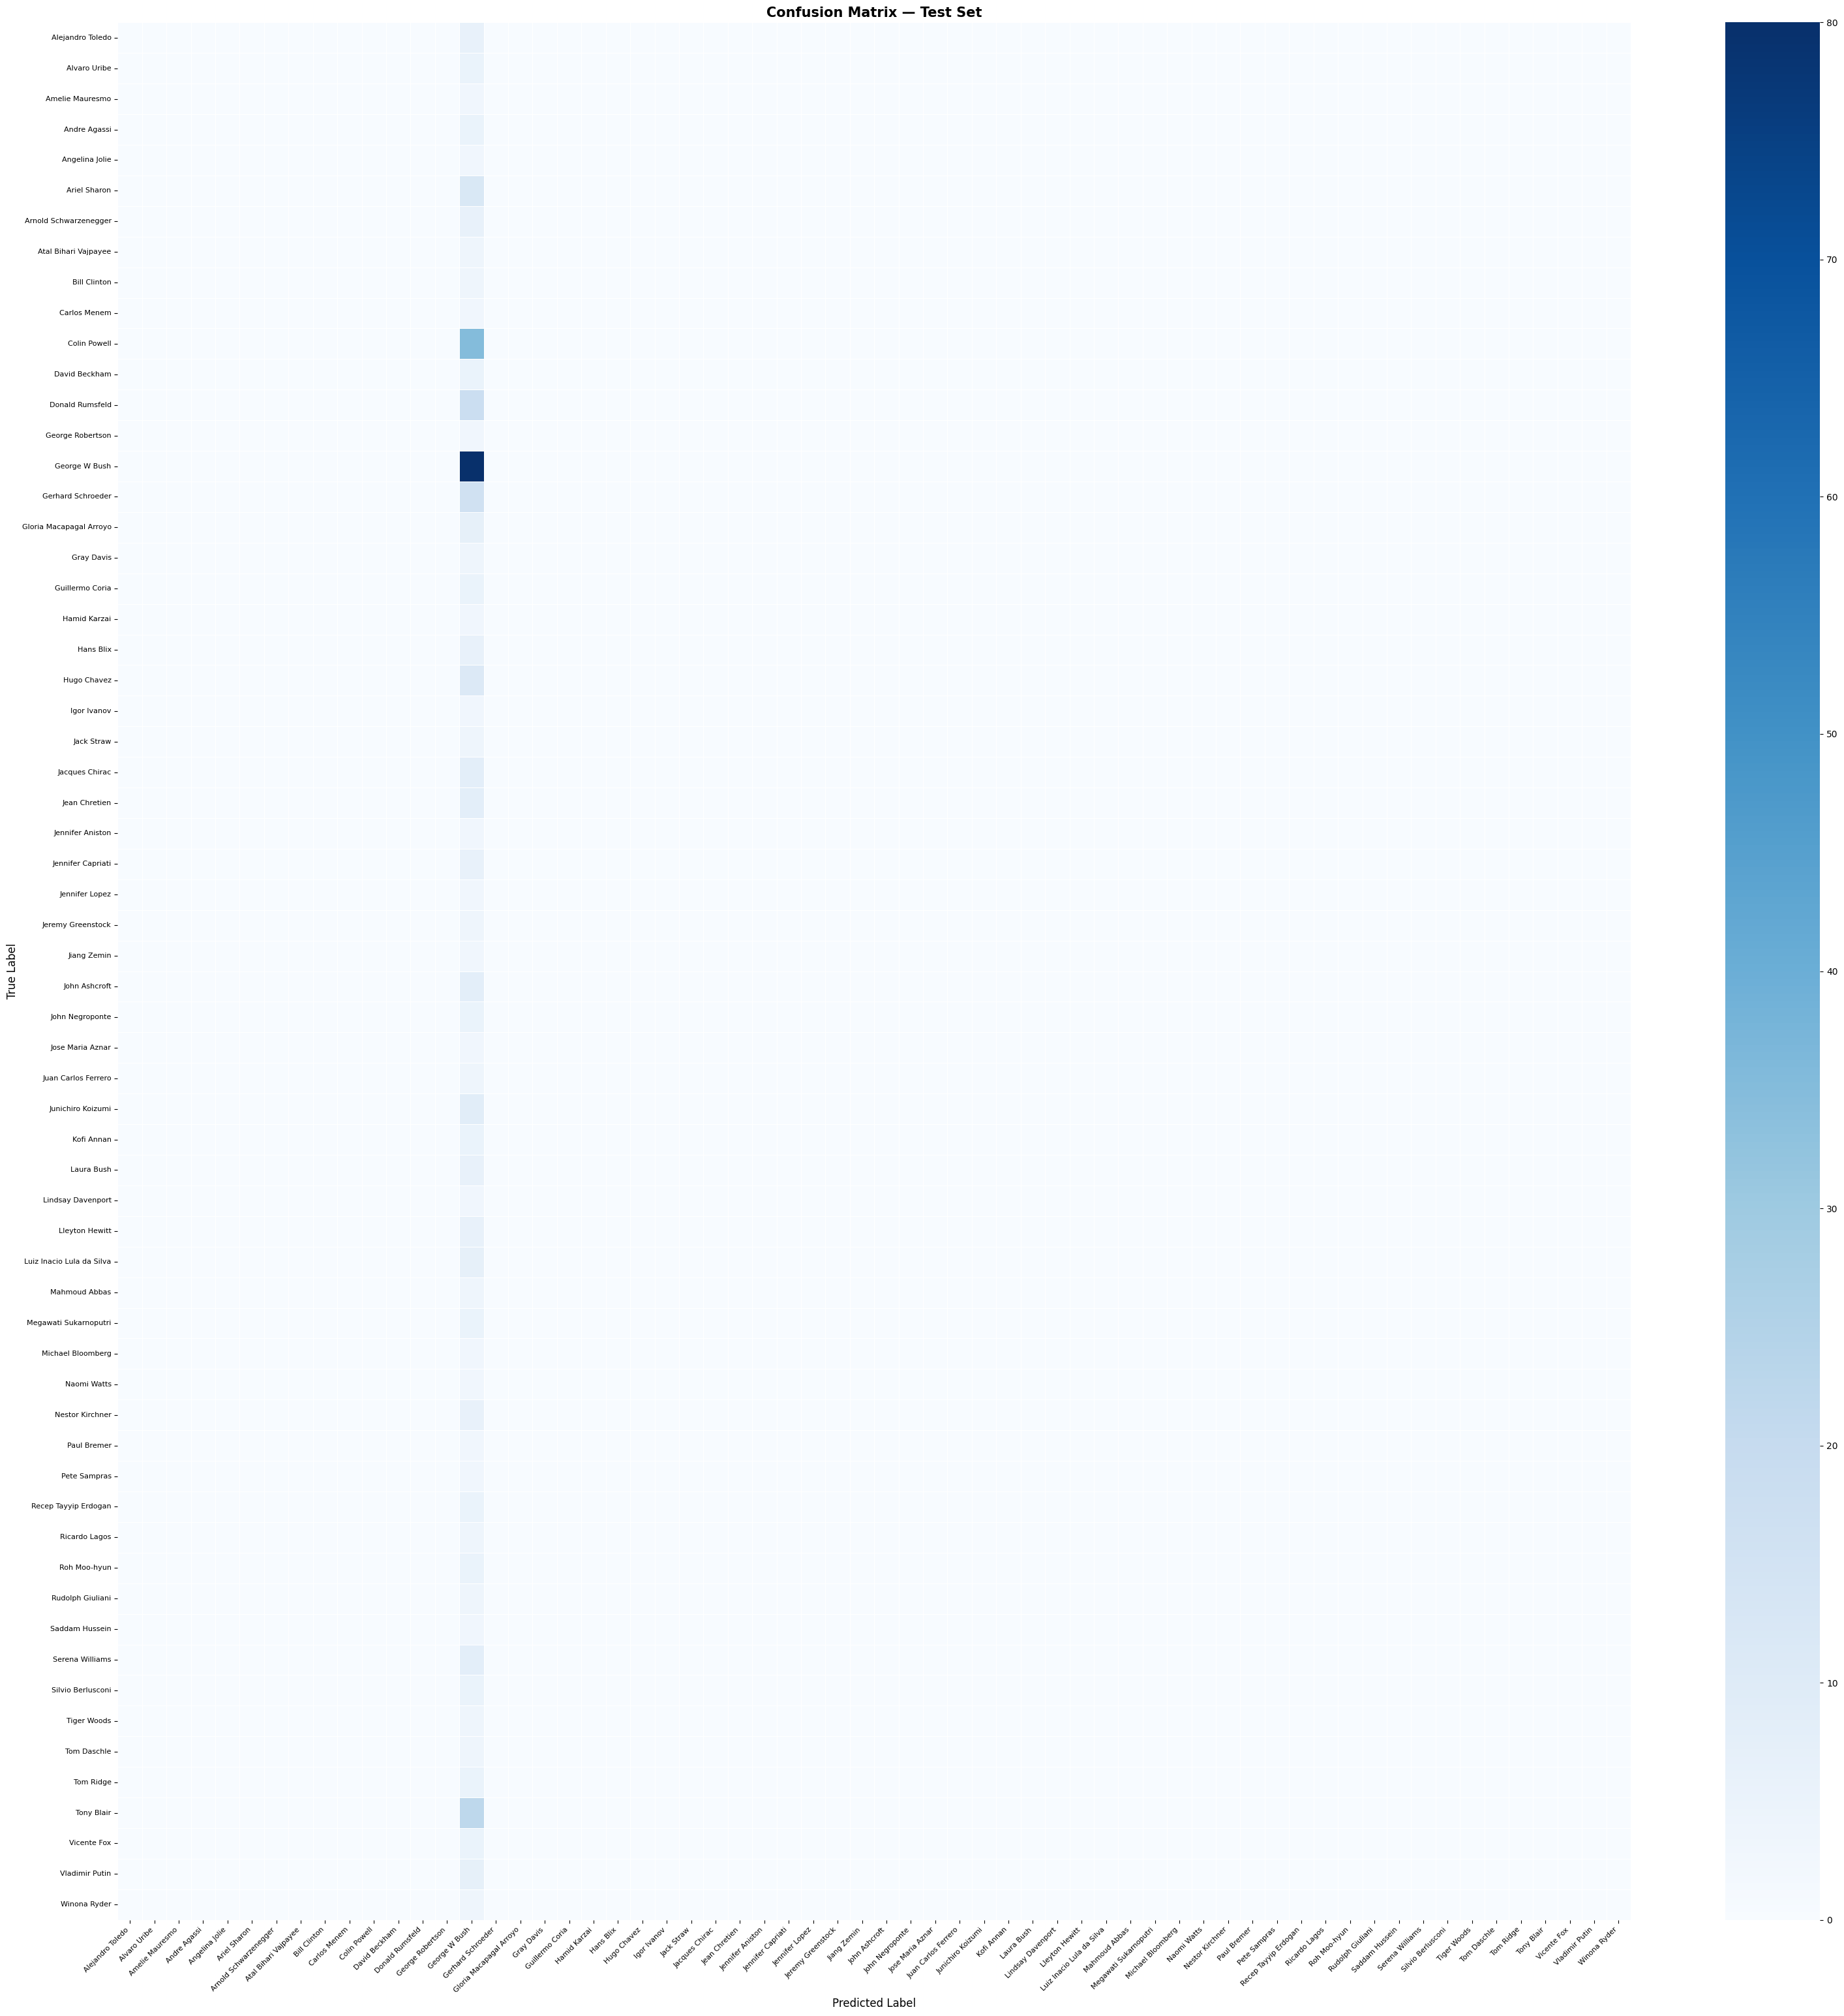

In [17]:
# Cell 17 - Confusion matrix
# Diagonal = correct predictions, off-diagonal = mistakes
# Only shows cell numbers when NUM_CLASSES <= 20 to avoid clutter

cm = confusion_matrix(y_true, y_pred)

# Scale the figure size with number of classes for readability
fig_size = max(10, NUM_CLASSES // 2)
fig, ax  = plt.subplots(figsize=(fig_size, fig_size))

sns.heatmap(
    cm,
    annot=(NUM_CLASSES <= 20),   # show cell counts only for small grids
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.5,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — Test Set', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


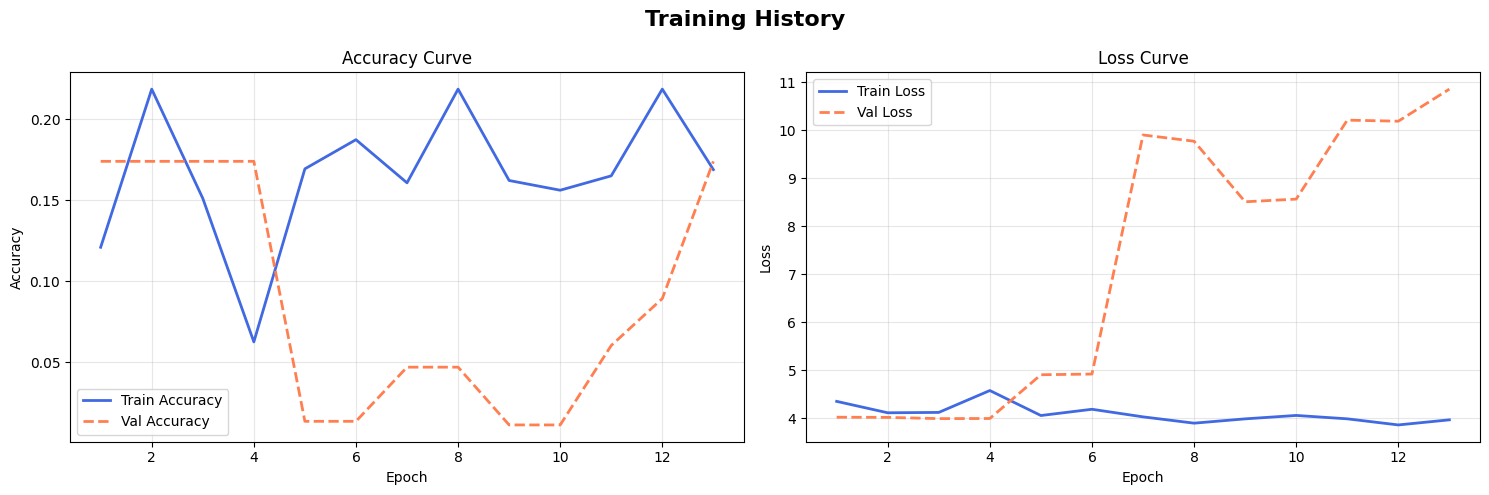

In [18]:
# Cell 18 - Plot training curves
# Train vs val accuracy/loss over epochs
# If val loss rises while train loss falls -> overfitting

hist       = history.history
epochs_ran = range(1, len(hist['accuracy']) + 1)   # x-axis: epoch numbers

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

# ── Left: Accuracy curve ──────────────────────────────────────────────────────
ax1.plot(epochs_ran, hist['accuracy'],     label='Train Accuracy',
         color='royalblue', lw=2)
ax1.plot(epochs_ran, hist['val_accuracy'], label='Val Accuracy',
         color='coral', lw=2, linestyle='--')
ax1.set_title('Accuracy Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Right: Loss curve ─────────────────────────────────────────────────────────
ax2.plot(epochs_ran, hist['loss'],     label='Train Loss',
         color='royalblue', lw=2)
ax2.plot(epochs_ran, hist['val_loss'], label='Val Loss',
         color='coral', lw=2, linestyle='--')
ax2.set_title('Loss Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# Cell 19 - Save the trained model and label encoder
# Saved in both .keras (recommended) and .h5 (legacy compatibility)
# LabelEncoder saved with pickle so we can decode predictions later
# Note: using 'fh' as the file handle variable to avoid naming conflicts

model.save('face_recognition_cnn_final.keras')

# Also save as .h5 for backwards compatibility with older environments
model.save('face_recognition_cnn_final.h5')

# Serialise the LabelEncoder so inference scripts can map integer → person name
with open('label_encoder.pkl', 'wb') as fh:   # BUG FIX: 'fh' not 'f'
    pickle.dump(le, fh)

print("Model saved  -> face_recognition_cnn_final.keras / .h5")
print("Encoder saved -> label_encoder.pkl")

# ── Verify the saved model loads correctly ────────────────────────────────────
reloaded = keras.models.load_model('face_recognition_cnn_final.keras')
print(f"\nReloaded model input  : {reloaded.input_shape}")
print(f"Reloaded model output : {reloaded.output_shape}")


Model saved  -> face_recognition_cnn_final.keras / .h5
Encoder saved -> label_encoder.pkl

Reloaded model input  : (None, 128, 128, 3)
Reloaded model output : (None, 62)


True label: Jacques Chirac


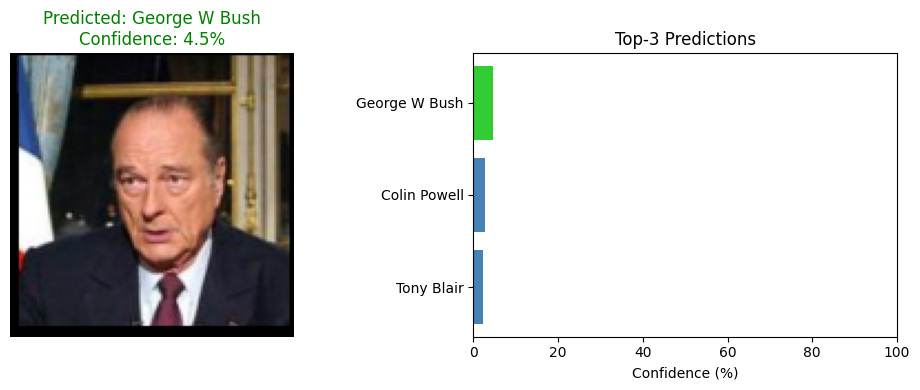


Top predictions:
  George W Bush                  4.55%
  Colin Powell                   2.82%
  Tony Blair                     2.35%


In [20]:
# Cell 20 - Prediction function
# Accepts either a file path or a numpy array as input.
# BUG FIX: if the array is already normalised to [0,1], skip dividing by 255
# (dividing twice would make the image nearly black and break predictions)

def predict_face(image_input, model, label_encoder, img_size=IMG_SIZE,
                 top_k=3, display=True):
    """
    Predict the identity of a face from an image.

    Args:
        image_input   : File path (str) OR numpy float32 array already in [0, 1].
        model         : Trained Keras model.
        label_encoder : Fitted LabelEncoder (maps integer index → person name).
        img_size      : Square image size the model expects (must match training).
        top_k         : Number of top predictions to return and display.
        display       : If True, show the image alongside a confidence bar chart.

    Returns:
        dict with keys:
            'name'       : str   — top predicted person name
            'confidence' : float — probability of the top prediction
            'top_k'      : list of (name, probability) tuples
    """
    # ── Step 1: load the image ─────────────────────────────────────────────────
    if isinstance(image_input, str):
        # Input is a file path — read with OpenCV (returns BGR uint8)
        img_bgr = cv2.imread(image_input)
        if img_bgr is None:
            raise FileNotFoundError(f"Cannot read image at: {image_input}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)   # BGR → RGB
        already_normalised = False   # raw uint8 pixel values [0, 255]
    else:
        # Input is a numpy array — use a copy to avoid mutating the original
        img_rgb = image_input.copy()
        # Detect if the array is already normalised (float, values <= 1.0)
        already_normalised = (img_rgb.dtype == np.float32 and img_rgb.max() <= 1.0)

    # ── Step 2: resize to the model's expected input size ─────────────────────
    img_resized = cv2.resize(
        img_rgb if already_normalised else img_rgb,
        (img_size, img_size)
    )

    # ── Step 3: normalise (only if not already in [0, 1]) ─────────────────────
    # BUG FIX: skip division when array is already float32 in [0, 1]
    if already_normalised:
        img_norm = img_resized.astype(np.float32)   # ensure float32, no rescale
    else:
        img_norm = img_resized.astype(np.float32) / 255.0   # uint8 → [0, 1]

    # ── Step 4: add batch dimension — model expects (1, H, W, C) ─────────────
    img_expanded = np.expand_dims(img_norm, axis=0)

    # ── Step 5: run inference ─────────────────────────────────────────────────
    probs       = model.predict(img_expanded, verbose=0)[0]   # shape: (NUM_CLASSES,)
    top_k_idx   = np.argsort(probs)[::-1][:top_k]             # indices of top-k probs
    top_k_names = label_encoder.inverse_transform(top_k_idx)  # integer → string name
    top_k_probs = probs[top_k_idx]

    result = {
        'name'       : top_k_names[0],
        'confidence' : float(top_k_probs[0]),
        'top_k'      : list(zip(top_k_names, top_k_probs.tolist()))
    }

    # ── Step 6: optionally visualise ──────────────────────────────────────────
    if display:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # Left panel: the face image with prediction title
        axes[0].imshow(np.clip(img_resized, 0, 1) if already_normalised
                       else img_resized.astype(np.uint8))
        axes[0].set_title(
            f"Predicted: {result['name'].replace('_', ' ')}\n"
            f"Confidence: {result['confidence'] * 100:.1f}%",
            fontsize=12, color='green'
        )
        axes[0].axis('off')

        # Right panel: horizontal bar chart of top-k probabilities
        names_display = [n.replace('_', ' ') for n, _ in result['top_k']]
        confs         = [p * 100 for _, p in result['top_k']]
        bar_colors    = ['limegreen'] + ['steelblue'] * (top_k - 1)
        axes[1].barh(names_display[::-1], confs[::-1], color=bar_colors[::-1])
        axes[1].set_xlabel('Confidence (%)')
        axes[1].set_title(f'Top-{top_k} Predictions')
        axes[1].set_xlim(0, 100)

        plt.tight_layout()
        plt.show()

    return result


# ── Demo: run the prediction function on a random test image ──────────────────
idx        = random.randint(0, len(X_test) - 1)
demo_image = X_test[idx]                                     # already normalised
true_label = le.inverse_transform([np.argmax(y_test[idx])])[0]

print(f"True label: {true_label.replace('_', ' ')}")
result = predict_face(demo_image, model, le, display=True)

print("\nTop predictions:")
for name, conf in result['top_k']:
    print(f"  {name.replace('_', ' '):<30} {conf * 100:.2f}%")


In [21]:
# Cell 21 - Real-time webcam prediction (Colab only)
# Injects JavaScript to access the browser webcam, captures one frame,
# encodes it as base64, and sends it back to Python for prediction
# To use: run the cell, allow camera access when prompted

from IPython.display import display, Javascript
from google.colab import output as colab_output
from base64 import b64decode
import io

def colab_capture_frame():
    """
    Inject JavaScript into the Colab cell output to open the webcam,
    wait 1 second for auto-exposure, capture one frame, and send the
    base64-encoded JPEG back to the Python kernel via a registered callback.
    """
    js = Javascript('''
        async function captureFrame() {
            // Request camera access from the browser
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            const video   = document.createElement('video');
            video.srcObject = stream;
            await video.play();

            // Wait 1 second so the camera can adjust brightness/focus
            await new Promise(r => setTimeout(r, 1000));

            // Draw the current video frame onto an off-screen canvas
            const canvas  = document.createElement('canvas');
            canvas.width  = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            // Stop all camera tracks (releases the hardware)
            stream.getTracks().forEach(t => t.stop());

            // Return the frame as a base64 JPEG data URL
            return canvas.toDataURL('image/jpeg', 0.9);
        }
        // Invoke Python callback with the captured frame data
        captureFrame().then(data => google.colab.kernel.invokeFunction(
            'notebook.captureFrame', [data], {}
        ));
    ''')
    display(js)


def colab_webcam_predict(model, label_encoder):
    """
    Capture one webcam frame in Colab and run face recognition on it.

    Args:
        model         : Trained Keras model.
        label_encoder : Fitted LabelEncoder for mapping class index → name.

    Returns:
        dict : Prediction result from predict_face() (may be empty if
               the frame has not been received yet when this returns).
    """
    captured = {}   # will be populated by the async callback below

    def handle_frame(data_url):
        """Callback invoked by JavaScript with the base64-encoded frame."""
        # Split 'data:image/jpeg;base64,<data>' into header and payload
        _, encoded  = data_url.split(',', 1)
        img_bytes   = b64decode(encoded)                         # decode base64 → bytes
        img_pil     = Image.open(io.BytesIO(img_bytes)).convert('RGB')  # bytes → PIL
        img_np      = np.array(img_pil, dtype=np.float32) / 255.0       # PIL → float32

        # Run prediction (img_np is already normalised, predict_face handles this)
        result = predict_face(img_np, model, label_encoder, display=True)
        captured['result'] = result
        print(f"\nIdentified as: {result['name'].replace('_', ' ')} "
              f"({result['confidence'] * 100:.1f}% confidence)")

    # Register the Python callback so JavaScript can invoke it
    colab_output.register_callback('notebook.captureFrame', handle_frame)

    # Inject and run the JavaScript webcam capture code
    colab_capture_frame()

    return captured

colab_webcam_predict(model, le)


<IPython.core.display.Javascript object>

{}